In [1]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os
from sklearn.model_selection import train_test_split
from scipy.io import loadmat
import seaborn as sns
sns.set_style("whitegrid")
from model import *
from torch.utils.data import DataLoader, Dataset

torch.set_default_dtype(torch.float64)

In [37]:
data = loadmat('dataset.mat')
X = data['X']
Y = data['X_dot']
t = data['T']
XX = np.append(X,t,axis=1)
X.shape, Y.shape, t.shape

# downsampling
X = X[:25000]
Y = Y[:25000]
t = t[:25000]
#XX = np.append(X,t,axis=1)
X.shape, Y.shape, t.shape

((25000, 2), (25000, 2), (25000, 1))

# Add noise

no_of_traj = 50
noise_level = 0.1   # 1% or np.sqrt(0.05) for 5%

M1 = 0
M2 = 0 

for i in range(no_of_traj):
    
    # first component
    M1 = M1 + np.abs( np.max( X[i:(i+1)*500,0] ) - np.min( X[i:(i+1)*500,0] ) )
    M2 = M2 + np.abs( np.max( X[i:(i+1)*500,1] ) - np.min( X[i:(i+1)*500,1] ) )

M1 = M1 / no_of_traj
M2 = M2 / no_of_traj

X_noise = np.zeros(X.shape)
X_noise[:,0] = X[:,0] + np.random.normal(0.0, noise_level, (X.shape[0],)) * M1
X_noise[:,1] = X[:,1] + np.random.normal(0.0, noise_level, (X.shape[0],)) * M2

XX = np.append(X_noise,t,axis=1)

In [38]:
# Add noise
noise_level = 0.1
X_noise = X + np.random.normal(0.0, noise_level, X.shape)
XX = np.append(X_noise,t,axis=1)

Text(0, 0.5, '$x_2$')

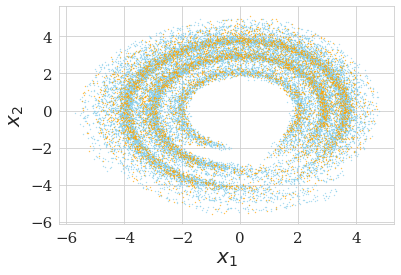

In [39]:
X_train, X_test, Y_train, Y_test = train_test_split(XX, Y, test_size=0.2)
# visualize train and test points
fontsize=15
plt.scatter(X_train[:,0], X_train[:,1], s=0.1, color='skyblue', label='training')
plt.scatter(X_test[:,0], X_test[:,1], s=0.1, color='orange', label='test')
plt.xticks(size = fontsize, fontname = 'serif')
plt.yticks(size = fontsize, fontname = 'serif')
plt.xlabel(r'$x_1$', size=20)
plt.ylabel(r'$x_2$', size=20)
#plt.legend(fontsize=10)
#plt.savefig("samples_van.pdf", bbox_inches = 'tight')

In [40]:
#Define LoadDataset
class LoadDataset(Dataset):
    def __init__(self, inputs, targets):
        self.x = inputs
        self.y = targets

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        inputs = self.x[idx, :]
        targets = self.y[idx, :]

        return inputs, targets

## Generate Non-trajectory data

In [26]:
######################## Non-trajectory
n = 20 #grid points where we do the recovery

#define recovery domain boundaries
x_low = -4
x_top = 4
t_low = 0
t_top = 5.

#generate grid of x and t in the recovery domain
x1 = np.linspace(x_low, x_top, n)
x2 = np.linspace(x_low, x_top, n)
time1 = np.linspace(t_low, t_top, n)
T,X1, X2 = np.meshgrid(time1,x1, x2)

mu = 0.02

#Generate input for netowrk
new_X1 = X1.reshape(-1,1)
new_X2 = X2.reshape(-1,1)
new_X = np.append(new_X1, new_X2, axis = 1)
new_T = T.reshape(-1,1)
X_new = np.append(new_X, new_T, axis = 1)
net_input = torch.from_numpy(X_new)

#compute true RHS on grid
Z1 = new_X2
Z2 = mu * (1-new_X1**2) * new_X2 - new_X1

Z = np.append(Z1,Z2,axis=1)

## Define and tain Lipschitz Neural network

In [45]:
epochs = 7
batch_size = 100
input_size = 3 #columns in input matrix point
hidden_size = 64
output_size = 2 

# Network
gamma = 3
Lipschitz_network = LipNN(input_size,hidden_size,hidden_size, output_size, gamma)

#load dataset to use when training 
dataset = LoadDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True) 
#select Optimizer and parameters
optimizer = torch.optim.Adam(Lipschitz_network.parameters(), lr=1e-2, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.0, amsgrad=False) 

loss = torch.nn.MSELoss()
train_loss = []

for epoch in range(epochs):
    
    for input_data, targets in dataloader:
        preds = Lipschitz_network(input_data) 
        l2_loss = loss(preds, targets)
        
        #optimizer step
        optimizer.zero_grad()
        l2_loss.backward()
        optimizer.step()
    
    # training loss
    y_pred = Lipschitz_network(torch.from_numpy(X_train))
    train_loss.append( loss(y_pred, torch.from_numpy(Y_train)).item() )

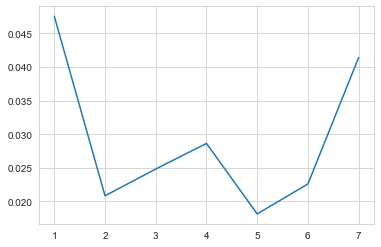

In [46]:
plt.plot(range(1,epochs+1),train_loss)

In [47]:
print('Lipschitz Neural Network: ')

# Compute training loss
y_pred = Lipschitz_network(torch.from_numpy(X_train))
Lipschitz_train_loss = loss(y_pred, torch.from_numpy(Y_train))
print('Training loss is {:.2e}'.format(Lipschitz_train_loss))

y_pred = Lipschitz_network(torch.from_numpy(X_test))
Lipschitz_test_loss = loss(y_pred, torch.from_numpy(Y_test))
print('Test loss is {:.2e}'.format(Lipschitz_test_loss))

# generalization gap
Lip_gap = Lipschitz_test_loss - Lipschitz_train_loss
print('Generalization gap is {:.2e}'.format(Lip_gap))

# Lipschitz Neural Network
Z_lip = Lipschitz_network(net_input).detach().numpy()

print('Recovery of the first component:')
print('Mean Relative Error on non-trajectory data {0:1.2f}%'.format(100*np.mean(abs(Z1.reshape(-1) - Z_lip[:,0]))/(np.abs(np.max(Z1)-np.min(Z1)))))

print('Recovery of the second component:')
print('Mean Relative Error on non-trajectory data {0:1.2f}%'.format(100*np.mean(abs(Z2.reshape(-1) - Z_lip[:,1]))/(np.abs(np.max(Z2)-np.min(Z2)))))


Lipschitz Neural Network: 
Training loss is 4.14e-02
Test loss is 4.15e-02
Generalization gap is 5.17e-05
Recovery of the first component:
Mean Relative Error on non-trajectory data 2.58%
Recovery of the second component:
Mean Relative Error on non-trajectory data 1.84%


## Lip-reg NN

In [48]:
epochs = 10
batch_size = 100
input_size = 3  #columns in input matrix point
hidden_size1 = 10
hidden_size2 = 30
output_size = 2 
reg_param = 0.005

how_many_points = 10

# Neural Network with Lip-regulariation term
Lip_reg = LipNet(input_size,hidden_size1,hidden_size2, output_size)

#load dataset to use when training 
dataset = LoadDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True) 
#select Optimizer and parameters
optimizer = torch.optim.Adam(Lip_reg.parameters(), lr=1e-2, betas=(0.9, 0.999), eps=1e-08, weight_decay=0.0, amsgrad=False) 

loss = torch.nn.MSELoss()
train_loss = []

for epoch in range(epochs):
    
    for input_data, targets in dataloader:
        preds = Lip_reg(input_data) 
        l2_loss = loss(preds, targets)
        Lips =  reg_param * Lip(input_data, how_many_points, Lip_reg)
        lo = l2_loss +  Lips
        
        #optimizer step
        optimizer.zero_grad()
        lo.backward()
        optimizer.step()
        
    # training loss
    y_pred = Lip_reg(torch.from_numpy(X_train))
    train_loss.append( loss(y_pred, torch.from_numpy(Y_train)).item() )

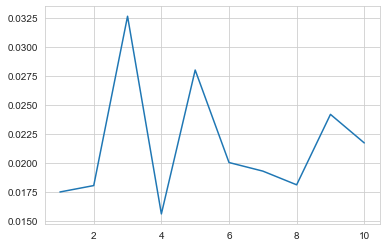

In [49]:
plt.plot(range(1,epochs+1),train_loss)

In [50]:
print('Lipschitz Regularized Neural Network')

# Compute training loss
y_pred = Lip_reg(torch.from_numpy(X_train))
Lip_reg_train_loss = loss(y_pred, torch.from_numpy(Y_train))
print('Training loss is {:.2e}'.format(Lip_reg_train_loss))

y_pred = Lip_reg(torch.from_numpy(X_test))
Lip_reg_test_loss = loss(y_pred, torch.from_numpy(Y_test))
print('Test loss is {:.2e}'.format(Lip_reg_test_loss))

# generalization gap
Lip_reg_gap = Lip_reg_test_loss - Lip_reg_train_loss
print('Generalization gap is {:.2e}'.format(Lip_reg_gap))

# Neural Network with Lip regularization
Z_reg = Lip_reg(net_input).detach().numpy()

print('Recovery of the first component:')
print('Mean Relative Error on non-trajectory data {0:1.2f}%'.format(100*np.mean(abs(Z1.reshape(-1) - Z_reg[:,0]))/(np.abs(np.max(Z1)-np.min(Z1)))))

print('Recovery of the second component:')
print('Mean Relative Error on non-trajectory data {0:1.2f}%'.format(100*np.mean(abs(Z2.reshape(-1) - Z_reg[:,1]))/(np.abs(np.max(Z2)-np.min(Z2)))))


Lipschitz Regularized Neural Network
Training loss is 2.17e-02
Test loss is 2.15e-02
Generalization gap is -1.59e-04
Recovery of the first component:
Mean Relative Error on non-trajectory data 0.89%
Recovery of the second component:
Mean Relative Error on non-trajectory data 1.51%


## Random Features

In [41]:
############## Model 1: regularization parameter is 0.0001

T = 50    # repeat random sampling 10 times

N = 50
sigma = 4
reg_param = 0.0001

Lip_const1 = 0
Lip_const2 = 0

RF_train = np.zeros(T)
RF_test = np.zeros(T)
RF_gap = np.zeros(T)
RF_rel = np.zeros((T,2))

for t in range(T):
    
    # generate random features
    W = np.random.randn(3,N) / sigma
    b = np.random.uniform(0, 2*np.pi, size=(N,))
    
    # compute random features matrix and coefficients
    A = np.cos(X_train @ W + b) * np.sqrt(2/N)
    # first component:
    c1 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train[:,0])
    # estimate Lipschitz constant
    Lip_const1 = Lip_const1 + np.sum( np.abs(c1.reshape(-1)) * np.linalg.norm(W,axis=0) )
    
    # second component:
    c2 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train[:,1])
    # estimate Lipschitz constant
    Lip_const2 = Lip_const2 + np.sum( np.abs(c2.reshape(-1)) * np.linalg.norm(W,axis=0) )
    
    # training loss
    RF_train[t] = ( np.sum((A @ c1 - Y_train[:,0])**2) + np.sum((A @ c2 - Y_train[:,1])**2) ) / A.shape[0]
    
    # test loss
    A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
    RF_test[t] = ( np.sum((A_test @ c1 - Y_test[:,0])**2) + np.sum((A_test @ c2 - Y_test[:,1])**2) ) / A_test.shape[0]

    # generalization gap
    RF_gap[t] = RF_test[t] - RF_train[t]
    
    # compute mean-relative error on non-trajectory data
    A = np.cos(X_new @ W + b) * np.sqrt(2/N)
    Z_RF = A @ c1
    RF_rel[t,0] = np.mean(abs(Z1.reshape(-1) - Z_RF))/ np.abs(np.max(Z1)-np.min(Z1))
    
    Z_RF = A @ c2
    RF_rel[t,1] = np.mean(abs(Z2.reshape(-1) - Z_RF))/ np.abs(np.max(Z2)-np.min(Z2))
    

print('Random Features:')
print(f'Training loss is {np.mean(RF_train):.2e}')
print(f'Test loss is {np.mean(RF_test):.2e}')
print(f'Generalization gap is {np.mean(RF_gap):.2e}')

print('First component:')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel[:,0])))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const1/T))

print('Second component:')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel[:,1])))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const2/T))

Random Features:
Training loss is 2.34e-02
Test loss is 2.31e-02
Generalization gap is -2.90e-04
First component:
Mean Relative Error on non-trajectory data is 0.72%
Estimated Lipschitz constant is 89.3120
Second component:
Mean Relative Error on non-trajectory data is 0.57%
Estimated Lipschitz constant is 141.4302


In [42]:
############## Model 1: regularization parameter is 0.0001

T = 50    # repeat random sampling 10 times

N = 50
sigma = 4
reg_param = 0.001

Lip_const1 = 0
Lip_const2 = 0

RF_train = np.zeros(T)
RF_test = np.zeros(T)
RF_gap = np.zeros(T)
RF_rel = np.zeros((T,2))

for t in range(T):
    
    # generate random features
    W = np.random.randn(3,N) / sigma
    b = np.random.uniform(0, 2*np.pi, size=(N,))
    
    # compute random features matrix and coefficients
    A = np.cos(X_train @ W + b) * np.sqrt(2/N)
    # first component:
    c1 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train[:,0])
    # estimate Lipschitz constant
    Lip_const1 = Lip_const1 + np.sum( np.abs(c1.reshape(-1)) * np.linalg.norm(W,axis=0) )
    
    # second component:
    c2 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train[:,1])
    # estimate Lipschitz constant
    Lip_const2 = Lip_const2 + np.sum( np.abs(c2.reshape(-1)) * np.linalg.norm(W,axis=0) )
    
    # training loss
    RF_train[t] = ( np.sum((A @ c1 - Y_train[:,0])**2) + np.sum((A @ c2 - Y_train[:,1])**2) ) / A.shape[0]
    
    # test loss
    A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
    RF_test[t] = ( np.sum((A_test @ c1 - Y_test[:,0])**2) + np.sum((A_test @ c2 - Y_test[:,1])**2) ) / A_test.shape[0]

    # generalization gap
    RF_gap[t] = RF_test[t] - RF_train[t]
    
    # compute mean-relative error on non-trajectory data
    A = np.cos(X_new @ W + b) * np.sqrt(2/N)
    Z_RF = A @ c1
    RF_rel[t,0] = np.mean(abs(Z1.reshape(-1) - Z_RF))/ np.abs(np.max(Z1)-np.min(Z1))
    
    Z_RF = A @ c2
    RF_rel[t,1] = np.mean(abs(Z2.reshape(-1) - Z_RF))/ np.abs(np.max(Z2)-np.min(Z2))
    

print('Random Features:')
print(f'Training loss is {np.mean(RF_train):.2e}')
print(f'Test loss is {np.mean(RF_test):.2e}')
print(f'Generalization gap is {np.mean(RF_gap):.2e}')

print('First component:')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel[:,0])))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const1/T))

print('Second component:')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel[:,1])))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const2/T))

Random Features:
Training loss is 2.34e-02
Test loss is 2.31e-02
Generalization gap is -2.94e-04
First component:
Mean Relative Error on non-trajectory data is 0.63%
Estimated Lipschitz constant is 51.0130
Second component:
Mean Relative Error on non-trajectory data is 0.51%
Estimated Lipschitz constant is 74.0630


In [43]:
############## Model 1: regularization parameter is 0.0001

T = 50    # repeat random sampling 10 times

N = 50
sigma = 4
reg_param = 0.01

Lip_const1 = 0
Lip_const2 = 0

RF_train = np.zeros(T)
RF_test = np.zeros(T)
RF_gap = np.zeros(T)
RF_rel = np.zeros((T,2))

for t in range(T):
    
    # generate random features
    W = np.random.randn(3,N) / sigma
    b = np.random.uniform(0, 2*np.pi, size=(N,))
    
    # compute random features matrix and coefficients
    A = np.cos(X_train @ W + b) * np.sqrt(2/N)
    # first component:
    c1 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train[:,0])
    # estimate Lipschitz constant
    Lip_const1 = Lip_const1 + np.sum( np.abs(c1.reshape(-1)) * np.linalg.norm(W,axis=0) )
    
    # second component:
    c2 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train[:,1])
    # estimate Lipschitz constant
    Lip_const2 = Lip_const2 + np.sum( np.abs(c2.reshape(-1)) * np.linalg.norm(W,axis=0) )
    
    # training loss
    RF_train[t] = ( np.sum((A @ c1 - Y_train[:,0])**2) + np.sum((A @ c2 - Y_train[:,1])**2) ) / A.shape[0]
    
    # test loss
    A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
    RF_test[t] = ( np.sum((A_test @ c1 - Y_test[:,0])**2) + np.sum((A_test @ c2 - Y_test[:,1])**2) ) / A_test.shape[0]

    # generalization gap
    RF_gap[t] = RF_test[t] - RF_train[t]
    
    # compute mean-relative error on non-trajectory data
    A = np.cos(X_new @ W + b) * np.sqrt(2/N)
    Z_RF = A @ c1
    RF_rel[t,0] = np.mean(abs(Z1.reshape(-1) - Z_RF))/ np.abs(np.max(Z1)-np.min(Z1))
    
    Z_RF = A @ c2
    RF_rel[t,1] = np.mean(abs(Z2.reshape(-1) - Z_RF))/ np.abs(np.max(Z2)-np.min(Z2))
    

print('Random Features:')
print(f'Training loss is {np.mean(RF_train):.2e}')
print(f'Test loss is {np.mean(RF_test):.2e}')
print(f'Generalization gap is {np.mean(RF_gap):.2e}')

print('First component:')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel[:,0])))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const1/T))

print('Second component:')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel[:,1])))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const2/T))

Random Features:
Training loss is 2.35e-02
Test loss is 2.32e-02
Generalization gap is -2.98e-04
First component:
Mean Relative Error on non-trajectory data is 0.59%
Estimated Lipschitz constant is 35.6280
Second component:
Mean Relative Error on non-trajectory data is 0.47%
Estimated Lipschitz constant is 43.5772


In [44]:
############## Model 1: regularization parameter is 0.0001

T = 50    # repeat random sampling 10 times

N = 50
sigma = 4
reg_param = 0

Lip_const1 = 0
Lip_const2 = 0

RF_train = np.zeros(T)
RF_test = np.zeros(T)
RF_gap = np.zeros(T)
RF_rel = np.zeros((T,2))

for t in range(T):
    
    # generate random features
    W = np.random.randn(3,N) / sigma
    b = np.random.uniform(0, 2*np.pi, size=(N,))
    
    # compute random features matrix and coefficients
    A = np.cos(X_train @ W + b) * np.sqrt(2/N)
    # first component:
    c1 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train[:,0])
    # estimate Lipschitz constant
    Lip_const1 = Lip_const1 + np.sum( np.abs(c1.reshape(-1)) * np.linalg.norm(W,axis=0) )
    
    # second component:
    c2 = np.linalg.solve(A.T@A + reg_param * np.diag(np.linalg.norm(W,axis=0)), A.T@Y_train[:,1])
    # estimate Lipschitz constant
    Lip_const2 = Lip_const2 + np.sum( np.abs(c2.reshape(-1)) * np.linalg.norm(W,axis=0) )
    
    # training loss
    RF_train[t] = ( np.sum((A @ c1 - Y_train[:,0])**2) + np.sum((A @ c2 - Y_train[:,1])**2) ) / A.shape[0]
    
    # test loss
    A_test = np.cos(X_test @ W + b) * np.sqrt(2/N)
    RF_test[t] = ( np.sum((A_test @ c1 - Y_test[:,0])**2) + np.sum((A_test @ c2 - Y_test[:,1])**2) ) / A_test.shape[0]

    # generalization gap
    RF_gap[t] = RF_test[t] - RF_train[t]
    
    # compute mean-relative error on non-trajectory data
    A = np.cos(X_new @ W + b) * np.sqrt(2/N)
    Z_RF = A @ c1
    RF_rel[t,0] = np.mean(abs(Z1.reshape(-1) - Z_RF))/ np.abs(np.max(Z1)-np.min(Z1))
    
    Z_RF = A @ c2
    RF_rel[t,1] = np.mean(abs(Z2.reshape(-1) - Z_RF))/ np.abs(np.max(Z2)-np.min(Z2))
    

print('Random Features:')
print(f'Training loss is {np.mean(RF_train):.2e}')
print(f'Test loss is {np.mean(RF_test):.2e}')
print(f'Generalization gap is {np.mean(RF_gap):.2e}')

print('First component:')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel[:,0])))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const1/T))

print('Second component:')
print('Mean Relative Error on non-trajectory data is {0:1.2f}%'.format(100*np.mean(RF_rel[:,1])))
print('Estimated Lipschitz constant is {:.4f}'.format(Lip_const2/T))

Random Features:
Training loss is 2.34e-02
Test loss is 2.31e-02
Generalization gap is -2.82e-04
First component:
Mean Relative Error on non-trajectory data is 0.87%
Estimated Lipschitz constant is 314.2900
Second component:
Mean Relative Error on non-trajectory data is 0.87%
Estimated Lipschitz constant is 503.7472
